MODEL Z PCA 
CV scores: [0.80833333 0.71388889 0.77715877 0.81337047 0.7632312 ]
Mean accuracy: 0.7751965335809347

 MODEL BEZ PCA 
CV scores: [0.91388889 0.88055556 0.94428969 0.9637883  0.89972145]
Mean accuracy: 0.9204487774682761


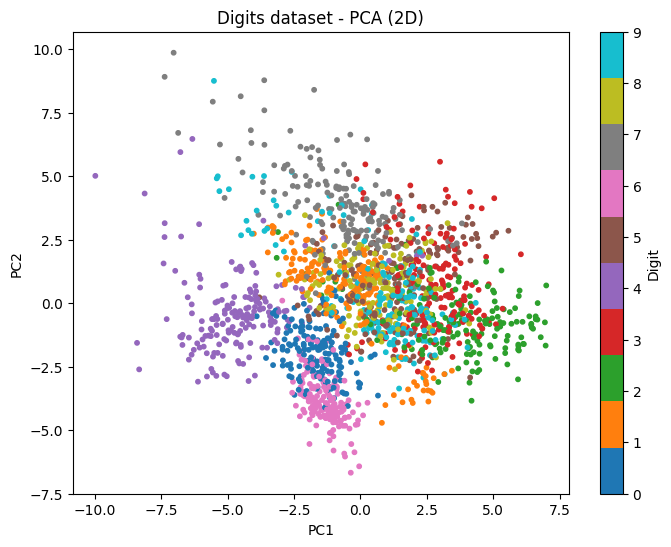

In [2]:
# Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.
# Dataset: Digits
# Wymagania:
# Pipeline z 3 krokami
# Cross-validation na całym pipeline
# Porównaj z modelem bez PCA

import numpy as np
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Wczytanie datasetu

digits = load_digits()

X = digits.data # macierz cech
y = digits.target #etykieta klas


# Pipeline z PCA

pipeline_pca = Pipeline([
    ("scaler", StandardScaler()), #skalowanie wszystkich cech
    ("pca", PCA(n_components=6)),
    ("logreg", LogisticRegression(max_iter=5000))
])

#PCA będzie faworyzować duże wartości.
#Dlatego scaling prawie zawsze robi się przed PCA.

# Cross-validation -> dzieli dane na 5 części

scores_pca = cross_val_score(
    pipeline_pca,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


# Pipeline bez PCA

pipeline_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

scores_no_pca = cross_val_score(
    pipeline_no_pca,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Wyniki

print("MODEL Z PCA ")
print("CV scores:", scores_pca)
print("Mean accuracy:", np.mean(scores_pca))

print()

print(" MODEL BEZ PCA ")
print("CV scores:", scores_no_pca)
print("Mean accuracy:", np.mean(scores_no_pca))

# Wizualizacja
# standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA do 2D
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# wykres
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=10
)

plt.title("Digits dataset - PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Digit")

plt.show()


In [ ]:
# Wytrenuj model LogisticRegression na datasecie Iris i oceń jego accuracy.
# Dataset: sklearn.datasets.load_iris()
# Wymagania:
# Podziel dane 80/20 (train/test)
# Zastosuj standaryzację
# Wydrukuj accuracy na zbiorze testowym

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix,classification_report)
from sklearn import cluster
from sklearn.datasets import load_iris
from sklearn import datasets

iris = load_iris()
X, y = iris.data, iris.target

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening modelu 
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predykcja
y_pred = model.predict(X_test_scaled)

# Metryki
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy na zbiorze testowym: {accuracy:.2%}")



Accuracy na zbiorze testowym: 93.33%


In [15]:
# Porównaj accuracy trzech algorytmów na datasecie Wine: LogisticRegression,
# DecisionTree, KNN.
# Dataset: sklearn.datasets.load_wine()
# Wymagania:
# Ten sam podział train/test dla wszystkich
# Wydrukuj wyniki w formie tabeli

import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Wczytywanie danych
dataset = load_wine()
X = wine.data
y = wine.target

# Podział na zbiór treningowy i testowy 
X_train, X_test, v_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Porównanie algorytmów
models = {
    'Logistic Regresion': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train) # Accuracy na train
    test_score = model.score(X_test, y_test)

    print(f"{name:25s} | Train: {train_score:.3f} | Test: {test_score:.3f}")

NameError: name 'wine' is not defined

KeyboardInterrupt: 

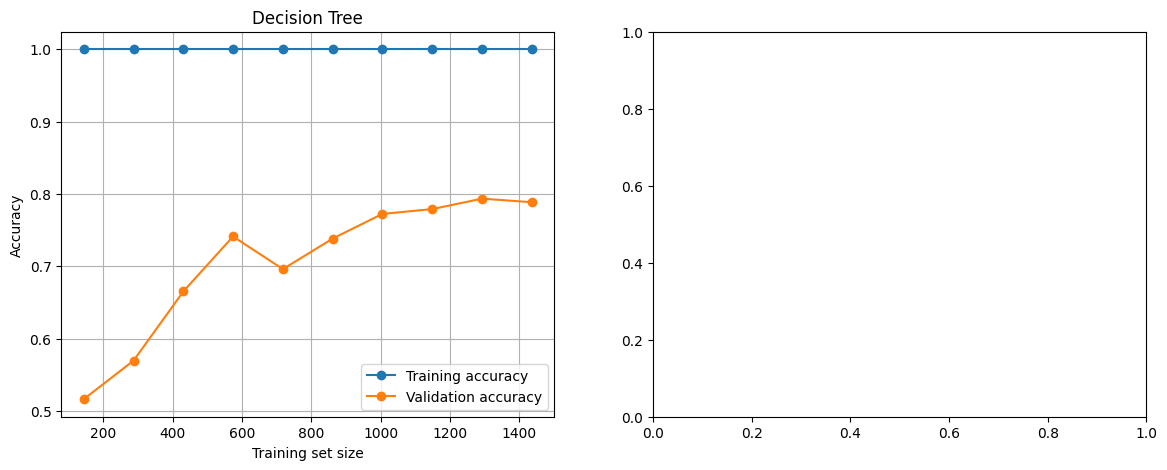

In [3]:
# Wygeneruj i zinterpretuj learning curves dla dwóch modeli.
# Dataset: Digits
# Wymagania:
# Decision Tree (max_depth=None) - potencjalny overfitting
# Random Forest (n_estimators=50, max_depth=5) - zbalansowany
# Wykresy obok siebie z interpretacją

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

digits = load_digits()
X, y = digits.data, digits.target

# model
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)
}

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, model) in zip(axes, models.items()):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    # średnie accuracy
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)


    # Wykres
  
    ax.plot(
        train_sizes,
        train_mean,
        label="Training accuracy",
        marker="o"
    )

    ax.plot(
        train_sizes,
        val_mean,
        label="Validation accuracy",
        marker="o"
    )

    ax.set_title(title)

    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()